## Heatmap for Toppers by Years

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [47]:
df =pd.read_csv("review-vc_sales_by_collection.csv")

In [49]:
df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [57]:
df['year'] = df['yr_month'].astype(str).str[:4]

In [65]:
topper_df = df[
    (df['financial_category']=='Toppers') &
    (df['year'].isin(['2022','2023','2024']))
].copy()

In [67]:
topper_df = topper_df[topper_df['collection'] != '__TOTAL__']

In [69]:
topper_df = topper_df.dropna(subset=['written_avg_rating'])

In [71]:
topper_df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year
389,202201,Toppers,4in Swirl Gel,3.6,1.0,5.0,0.20,NaN,NaN,NaN,NaN,18428.11,278.0,2022
390,202201,Toppers,4in PRMF w Cover,5.0,0.0,1.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,2022
392,202201,Toppers,4in MyGel,5.0,0.0,1.0,0.00,NaN,NaN,NaN,NaN,20457.60,186.0,2022
394,202201,Toppers,4in GT MF,4.0,2.0,10.0,0.20,NaN,NaN,NaN,NaN,48634.93,425.0,2022
396,202201,Toppers,3in Ultra Cooling Gel w Cover,2.0,1.0,1.0,1.00,NaN,NaN,NaN,NaN,2260.76,14.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21322,202412,Toppers,2in SWFT w WonderBox,2.0,1.0,1.0,1.00,2.0,1.0,1.0,1.00,6341.03,155.0,2024
21325,202412,Toppers,2in MGT w WonderBox,5.0,0.0,1.0,0.00,5.0,0.0,1.0,0.00,4294.27,106.0,2024
21326,202412,Toppers,2in GTFT w WonderBox,4.0,0.0,2.0,0.00,4.0,0.0,2.0,0.00,6510.57,122.0,2024
21333,202412,Toppers,1.5in Swirl Gel,3.5,1.0,4.0,0.25,3.5,1.0,4.0,0.25,17250.18,485.0,2024


In [77]:
top_cols = (
    topper_df.groupby('collection')['sales_amount']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

In [79]:
top_cols

Index(['1.5in Swirl Gel', '4in GT MF', '2in Swirl Gel', '3in Swirl Gel',
       '3in GT MF', '1.5in GT MF', '4in MyGel', '4in GTFT w WonderBox',
       '2in MyGel', '4in Swirl Gel', '3in GTFT w WonderBox', '3in MyGel',
       '2in Swirl Copper', '1in GT Zoned Gel', '1.5in SWFT w WonderBox',
       '2in SWFT w WonderBox', '3in Ultra Cooling Gel w Cover',
       '2in GT Zoned Gel', '4in SWFT w WonderBox', '3in GT Zoned Gel',
       '2in Ultra Cooling Gel w Cover', '3in MGT w WonderBox',
       '3in SWFT w WonderBox', '1.5in MyGel', '3in Swirl Copper',
       '4in MGT w WonderBox', '2in GTFT w WonderBox', '2in MGT w WonderBox',
       '4in Cloud w Cover', '4in GT TorsoTec MF'],
      dtype='object', name='collection')

In [81]:
topper_cols = topper_df[topper_df['collection'].isin(top_cols)].copy()

In [83]:
topper_cols['rating_bin'] = topper_cols['written_avg_rating'].round(1)

In [85]:
topper_cols

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year,rating_bin
389,202201,Toppers,4in Swirl Gel,3.600000,1.0,5.0,0.200000,NaN,NaN,NaN,NaN,18428.11,278.0,2022,3.6
392,202201,Toppers,4in MyGel,5.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,20457.60,186.0,2022,5.0
394,202201,Toppers,4in GT MF,4.000000,2.0,10.0,0.200000,NaN,NaN,NaN,NaN,48634.93,425.0,2022,4.0
396,202201,Toppers,3in Ultra Cooling Gel w Cover,2.000000,1.0,1.0,1.000000,NaN,NaN,NaN,NaN,2260.76,14.0,2022,2.0
397,202201,Toppers,3in Swirl Gel,1.918919,28.0,37.0,0.756757,NaN,NaN,NaN,NaN,125202.68,1951.0,2022,1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21322,202412,Toppers,2in SWFT w WonderBox,2.000000,1.0,1.0,1.000000,2.0,1.0,1.0,1.00,6341.03,155.0,2024,2.0
21325,202412,Toppers,2in MGT w WonderBox,5.000000,0.0,1.0,0.000000,5.0,0.0,1.0,0.00,4294.27,106.0,2024,5.0
21326,202412,Toppers,2in GTFT w WonderBox,4.000000,0.0,2.0,0.000000,4.0,0.0,2.0,0.00,6510.57,122.0,2024,4.0
21333,202412,Toppers,1.5in Swirl Gel,3.500000,1.0,4.0,0.250000,3.5,1.0,4.0,0.25,17250.18,485.0,2024,3.5


In [87]:
rating_bins = np.round(np.arange(1.0,5.1,0.1),1)

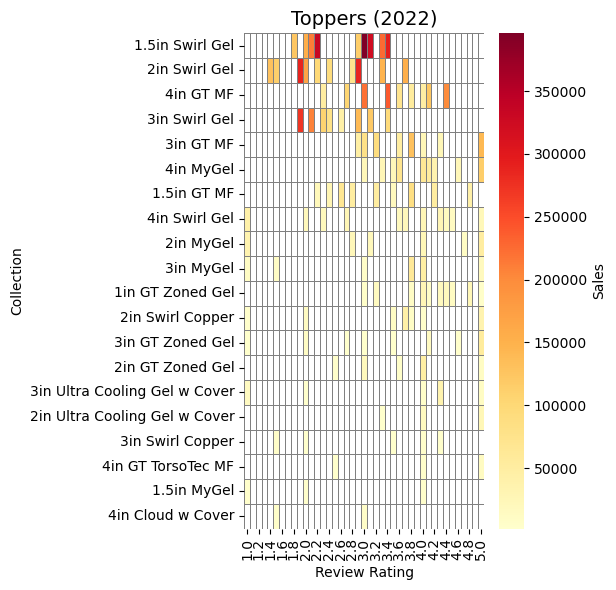

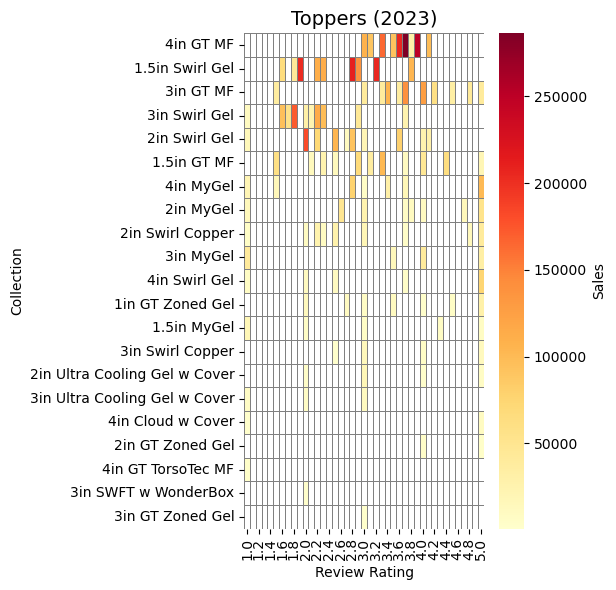

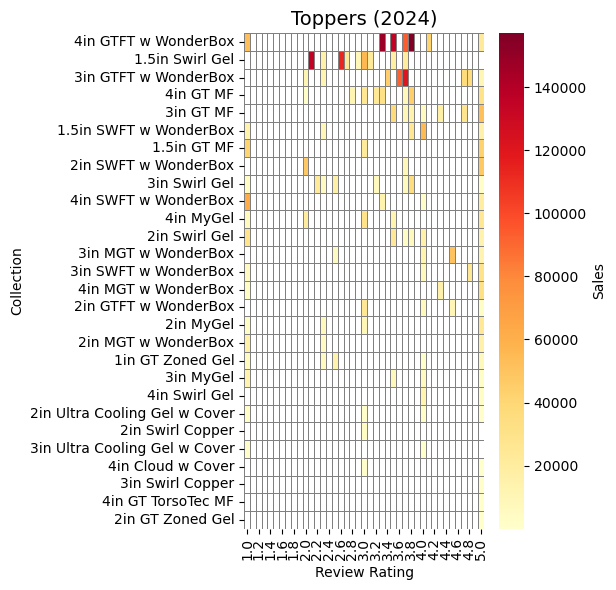

In [93]:
for year in ['2022','2023','2024']:
    pivot = (
        topper_cols[topper_cols['year']==year]
        .groupby(['collection','rating_bin'])['sales_amount']
        .sum()
        .unstack(fill_value=0)
       # .sort_index()
    )

    #누락 평점 구간을 포함시키고 정렬
    pivot = pivot.reindex(columns=rating_bins, fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # 힌색으로 마스킹 하기
    mask = pivot == 0
    
    plt.figure(figsize=(6,6))
    sns.heatmap(pivot, cmap='YlOrRd', mask=mask, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Sales'}, square=False)
                                                                                  
    plt.title(f'Toppers ({year})', fontsize=14)
    plt.xlabel('Review Rating')
    plt.ylabel('Collection')
    plt.tight_layout()
    plt.show()
    